# 01 — Exploratory Data Analysis
Student Success Analytics Platform

In [1]:
#importing libraries

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import engineer_features

print("libraries loaded")

libraries loaded


In [2]:
#loading data
df = pd.read_csv("../data/raw/enhanced_student_habits_performance_dataset.csv")

print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("\nmissing values:", df.isnull().sum().sum())

shape: (80000, 31)
columns: ['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']

missing values: 0


In [3]:
# create output directories if they don't exist
import os
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)
print("directories ready")

#column types overview
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

#drop student_id from numeric — not a feature
num_cols = [c for c in num_cols if c != 'student_id']

print("numeric columns:", len(num_cols))
print(num_cols)
print("\ncategorical columns:", len(cat_cols))
print(cat_cols)

directories ready
numeric columns: 18
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'previous_gpa', 'semester', 'stress_level', 'social_activity', 'screen_time', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'time_management_score', 'exam_score']

categorical columns: 12
['gender', 'major', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation', 'dropout_risk', 'study_environment', 'access_to_tutoring', 'family_income_range', 'learning_style']


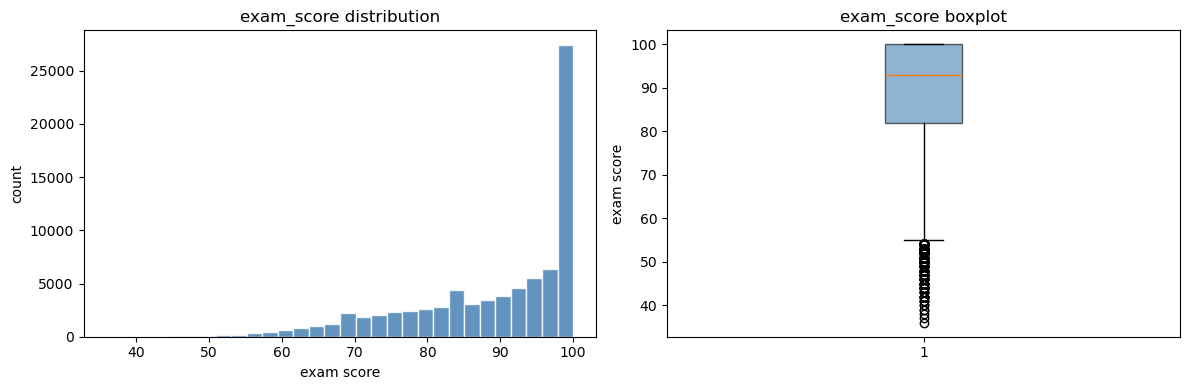

exam_score stats:
count    80000.00
mean        89.14
std         11.59
min         36.00
25%         82.00
50%         93.00
75%        100.00
max        100.00
Name: exam_score, dtype: float64

skewness: -1.028
note: heavily left-skewed — 75th percentile is 100 (ceiling)


In [4]:
#target 1: exam_score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['exam_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('exam_score distribution')
axes[0].set_xlabel('exam score')
axes[0].set_ylabel('count')

axes[1].boxplot(df['exam_score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('exam_score boxplot')
axes[1].set_ylabel('exam score')

plt.tight_layout()
plt.savefig("../data/processed/eda_exam_score_dist.png", dpi=130)
plt.show()

print("exam_score stats:")
print(df['exam_score'].describe().round(2))
print(f"\nskewness: {df['exam_score'].skew():.3f}")
print("note: heavily left-skewed — 75th percentile is 100 (ceiling)")

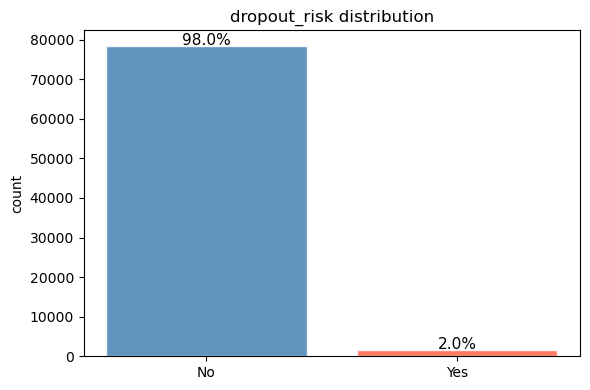

dropout_risk counts:
dropout_risk
No     78418
Yes     1582
Name: count, dtype: int64

⚠️  severe class imbalance — 98% No, 2% Yes
will require SMOTE or class_weight balancing in modeling notebooks


In [5]:
#target 2: dropout_risk distribution
counts = df['dropout_risk'].value_counts()
props  = df['dropout_risk'].value_counts(normalize=True).round(4)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=['steelblue','tomato'], alpha=0.85, edgecolor='white')
ax.set_title('dropout_risk distribution')
ax.set_ylabel('count')

for bar, prop in zip(bars, props.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{prop*100:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("../data/processed/eda_dropout_dist.png", dpi=130)
plt.show()

print("dropout_risk counts:")
print(counts)
print("\n⚠️  severe class imbalance — 98% No, 2% Yes")
print("will require SMOTE or class_weight balancing in modeling notebooks")

In [6]:
#grade tier engineering (exam_score → category)
#useful for classification variant and bias analysis
def grade_tier(score):
    if score >= 90: return 'A'
    elif score >= 75: return 'B'
    elif score >= 60: return 'C'
    else: return 'D/F'

df['grade_tier'] = df['exam_score'].apply(grade_tier)

print("grade tier distribution:")
print(df['grade_tier'].value_counts())
print(df['grade_tier'].value_counts(normalize=True).round(3))

grade tier distribution:
grade_tier
A      47771
B      21173
C       9731
D/F     1325
Name: count, dtype: int64
grade_tier
A      0.597
B      0.265
C      0.122
D/F    0.017
Name: proportion, dtype: float64


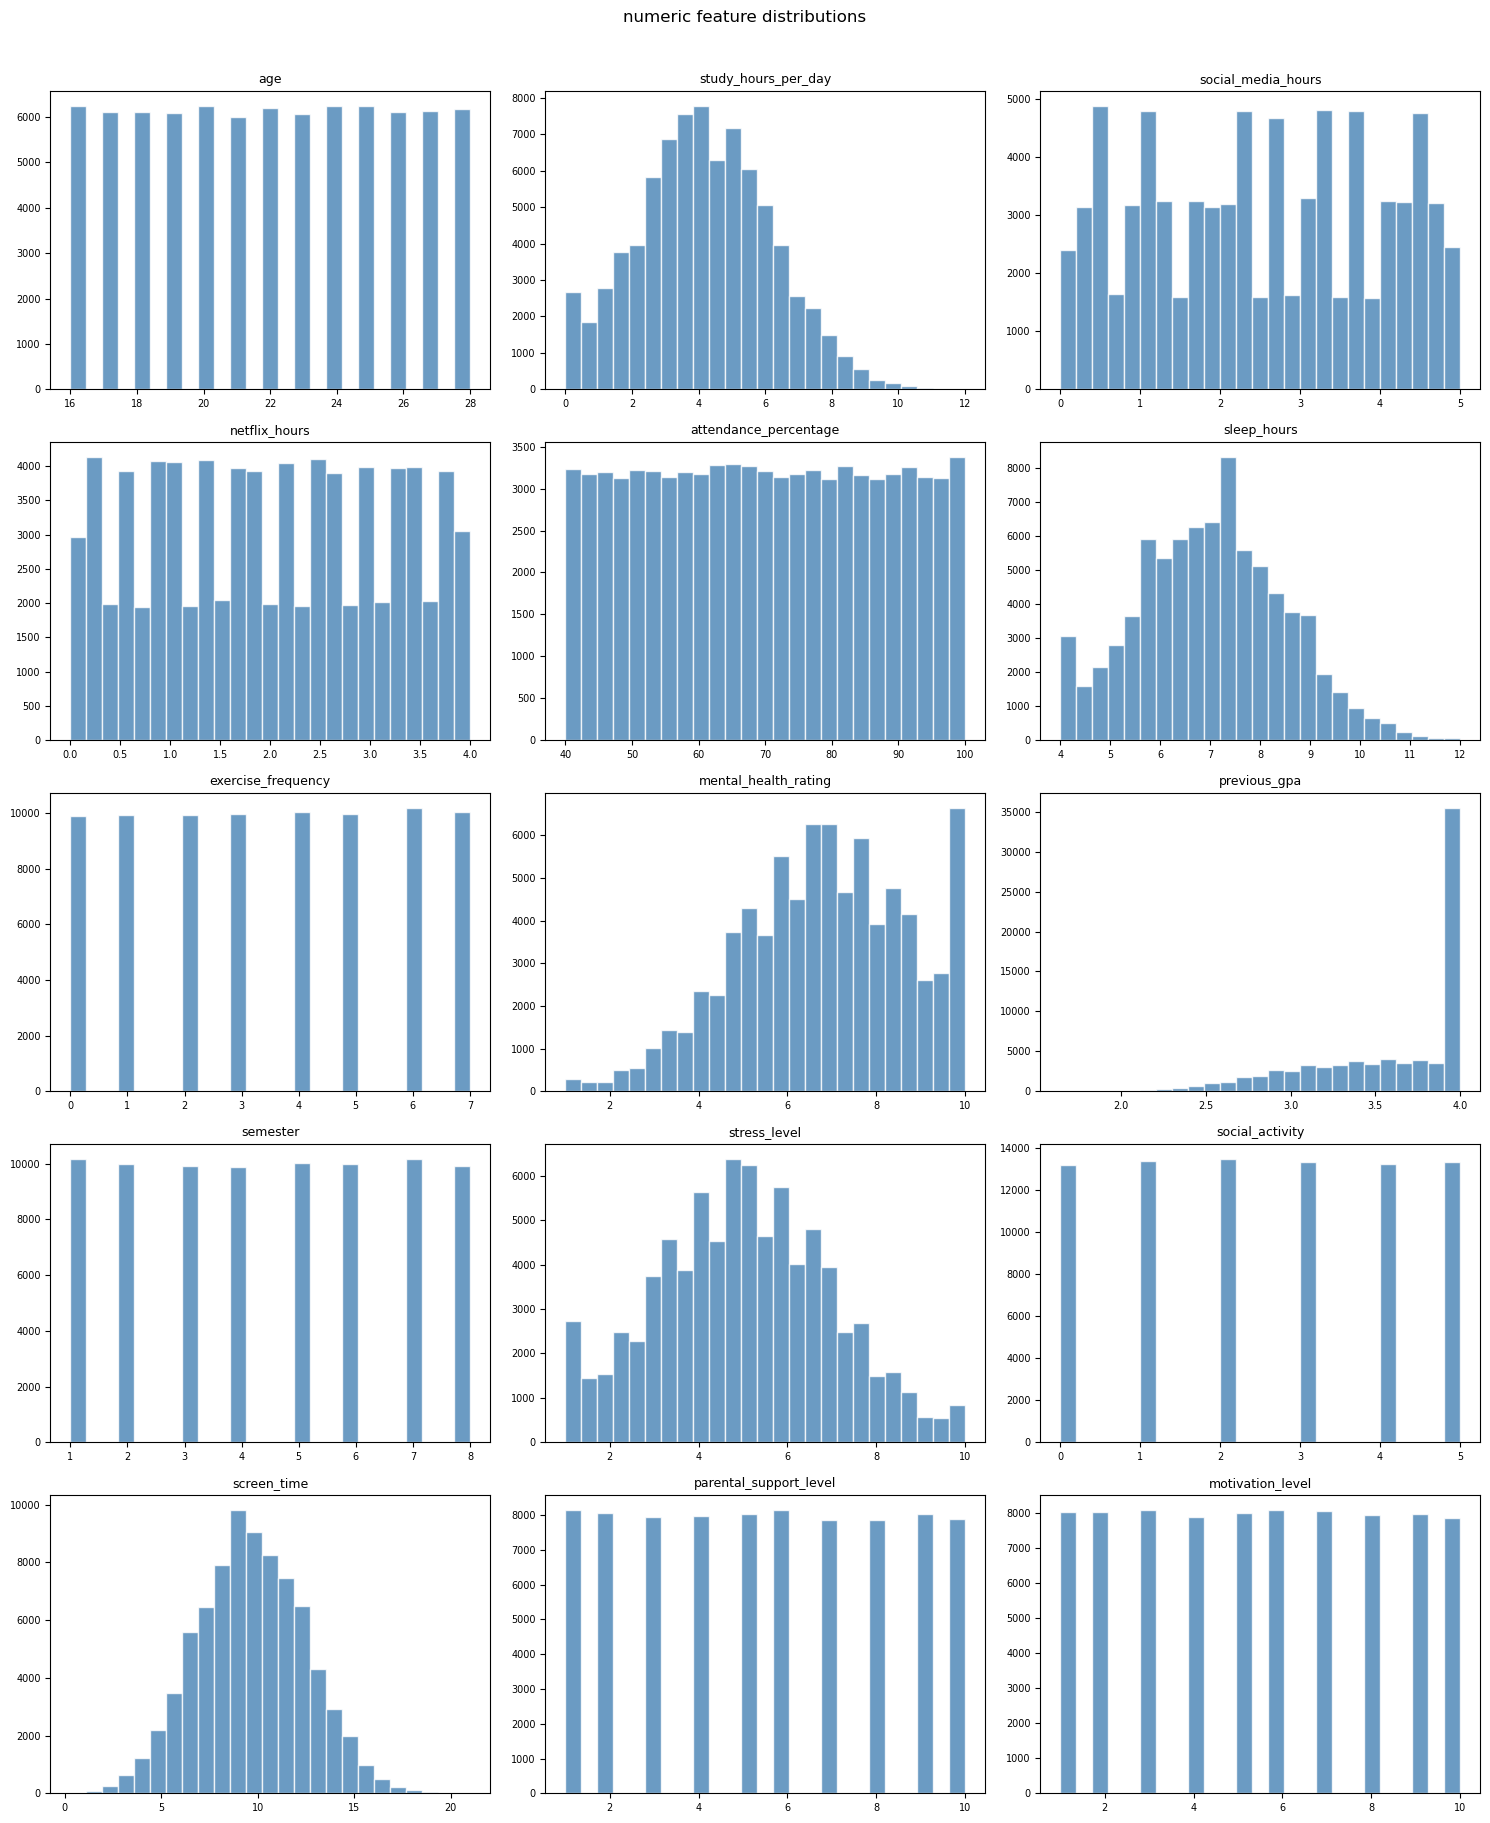

In [7]:
#numeric feature distributions
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

plot_cols = [c for c in num_cols if c != 'exam_score'][:15]

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('numeric feature distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_numeric_dists.png", dpi=120)
plt.show()

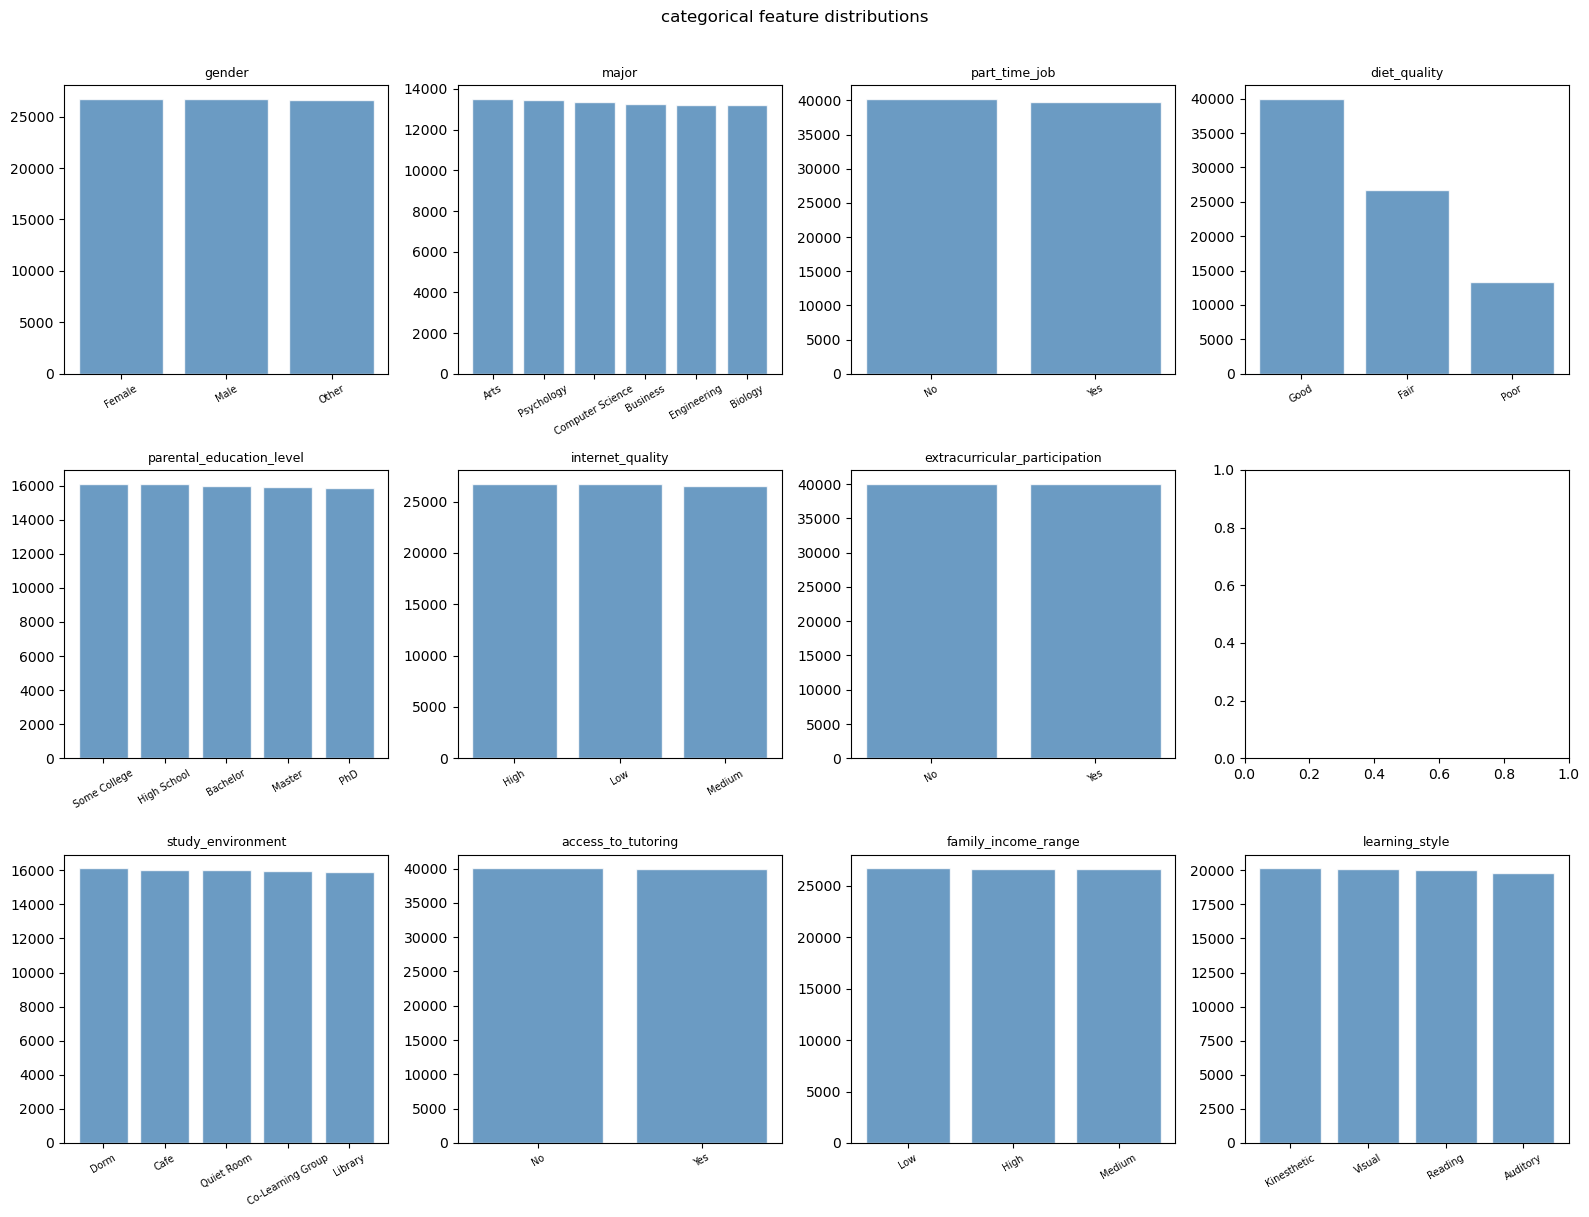

In [8]:
#categorical feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col == 'dropout_risk': continue
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('categorical feature distributions', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_categorical_dists.png", dpi=120)
plt.show()

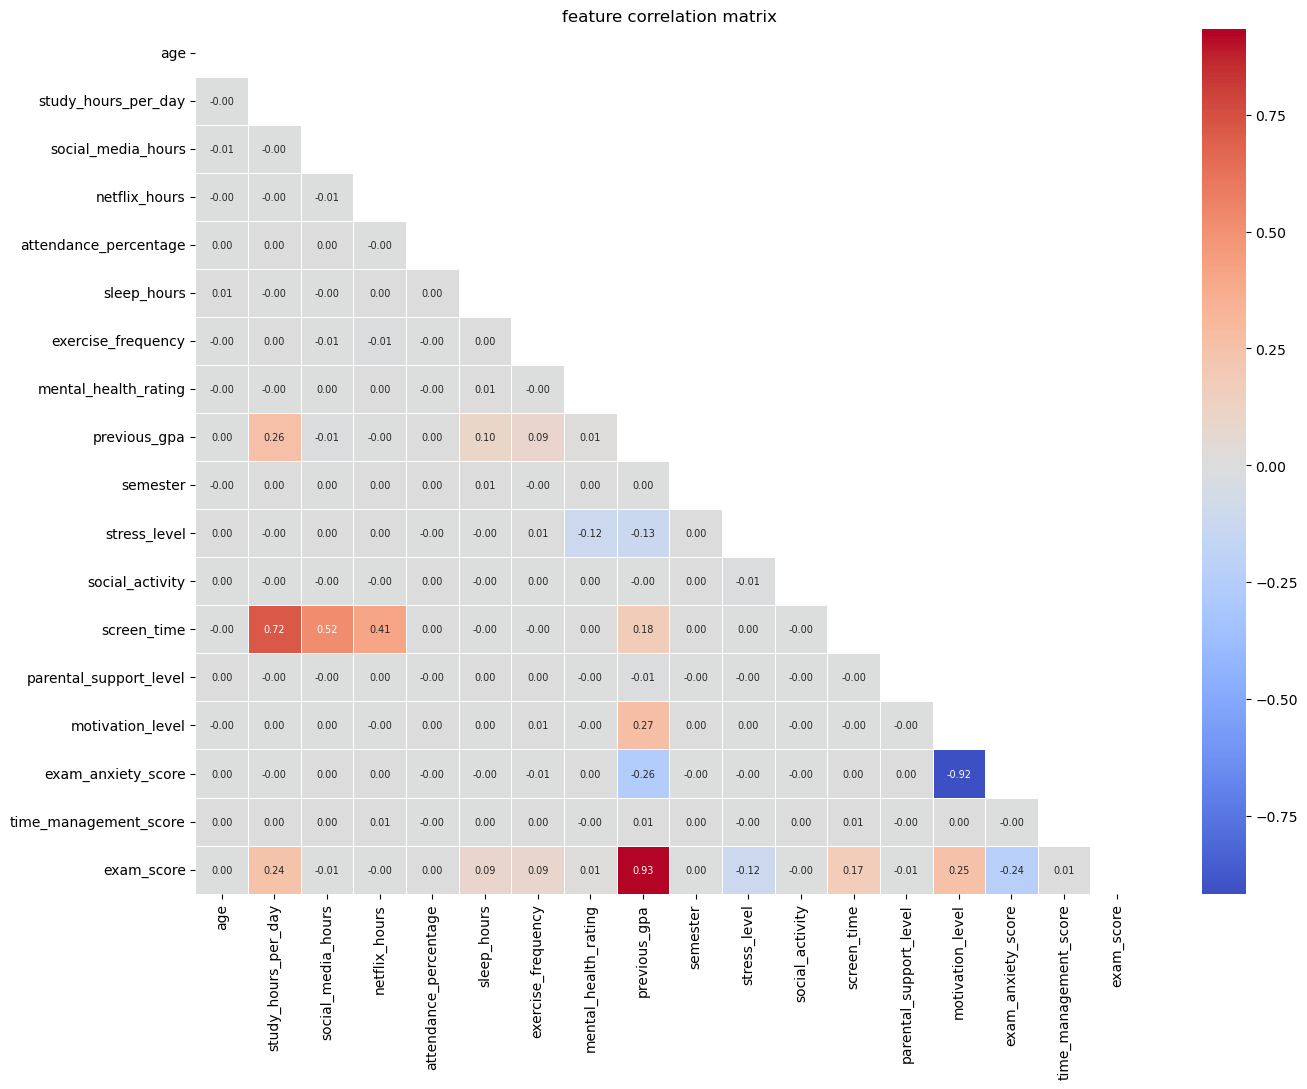

top correlations with exam_score:
previous_gpa              0.933
motivation_level          0.250
study_hours_per_day       0.241
exam_anxiety_score        0.236
screen_time               0.170
stress_level              0.119
sleep_hours               0.091
exercise_frequency        0.087
mental_health_rating      0.011
social_media_hours        0.006
parental_support_level    0.006
time_management_score     0.006
attendance_percentage     0.003
social_activity           0.003
netflix_hours             0.001
semester                  0.001
age                       0.000
Name: exam_score, dtype: float64


In [9]:
#correlation heatmap — numeric features vs exam_score
corr_cols = [c for c in num_cols if c != 'exam_score'] + ['exam_score']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size':7})

ax.set_title('feature correlation matrix', fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation_heatmap.png", dpi=130)
plt.show()

#top correlations with exam_score
exam_corr = corr['exam_score'].drop('exam_score').abs().sort_values(ascending=False)
print("top correlations with exam_score:")
print(exam_corr.round(3))

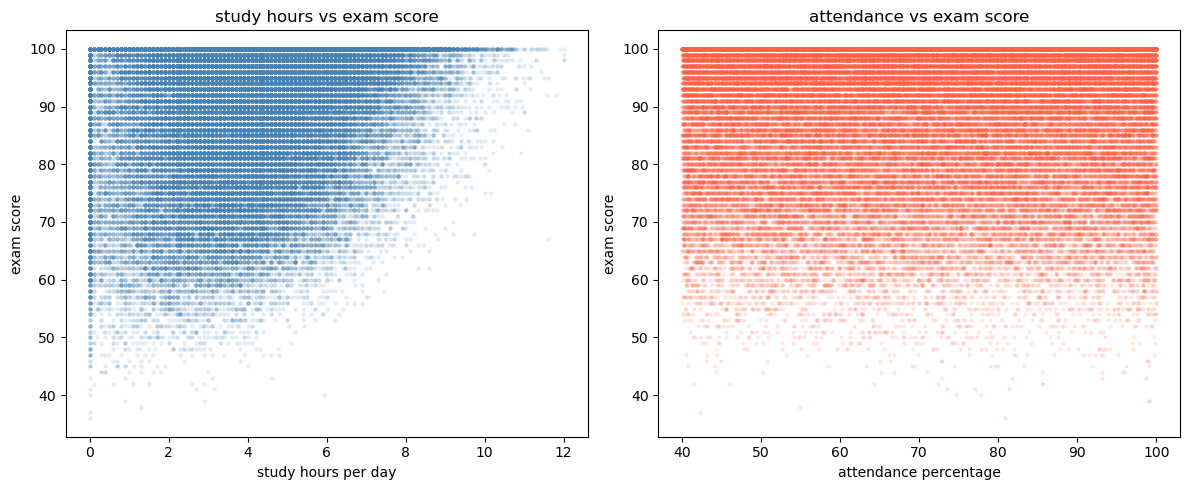

In [10]:
#key relationship: study_hours vs exam_score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['study_hours_per_day'], df['exam_score'],
                alpha=0.1, color='steelblue', s=5)
axes[0].set_xlabel('study hours per day')
axes[0].set_ylabel('exam score')
axes[0].set_title('study hours vs exam score')

#attendance vs exam_score
axes[1].scatter(df['attendance_percentage'], df['exam_score'],
                alpha=0.1, color='tomato', s=5)
axes[1].set_xlabel('attendance percentage')
axes[1].set_ylabel('exam score')
axes[1].set_title('attendance vs exam score')

plt.tight_layout()
plt.savefig("../data/processed/eda_key_relationships.png", dpi=130)
plt.show()

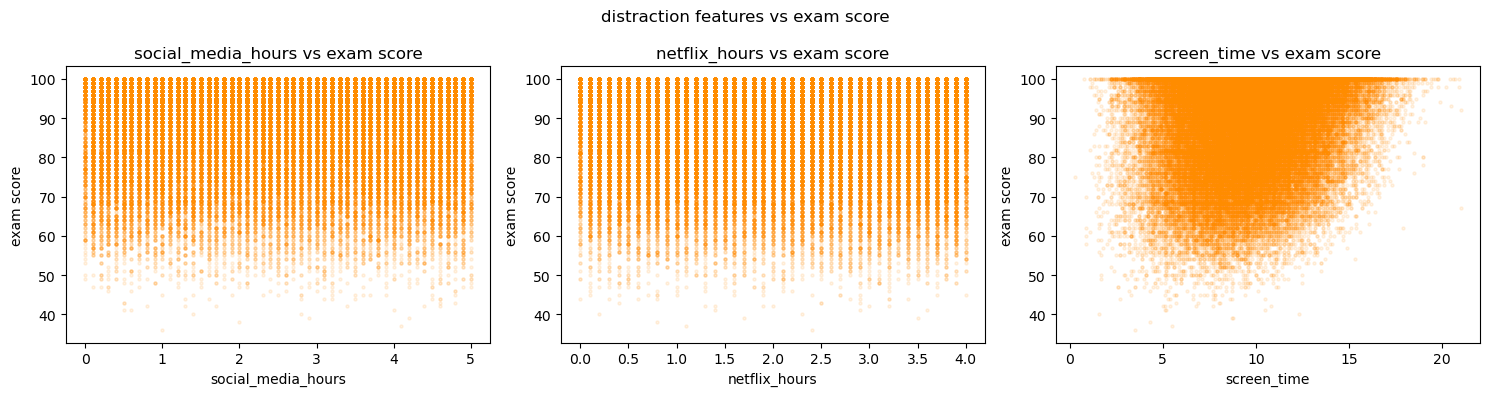

In [11]:
#distraction hours: social media + netflix + screen time vs exam_score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

distraction_cols = ['social_media_hours', 'netflix_hours', 'screen_time']

for i, col in enumerate(distraction_cols):
    axes[i].scatter(df[col], df['exam_score'],
                    alpha=0.1, color='darkorange', s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('exam score')
    axes[i].set_title(f'{col} vs exam score')

plt.suptitle('distraction features vs exam score', fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_distractions.png", dpi=130)
plt.show()

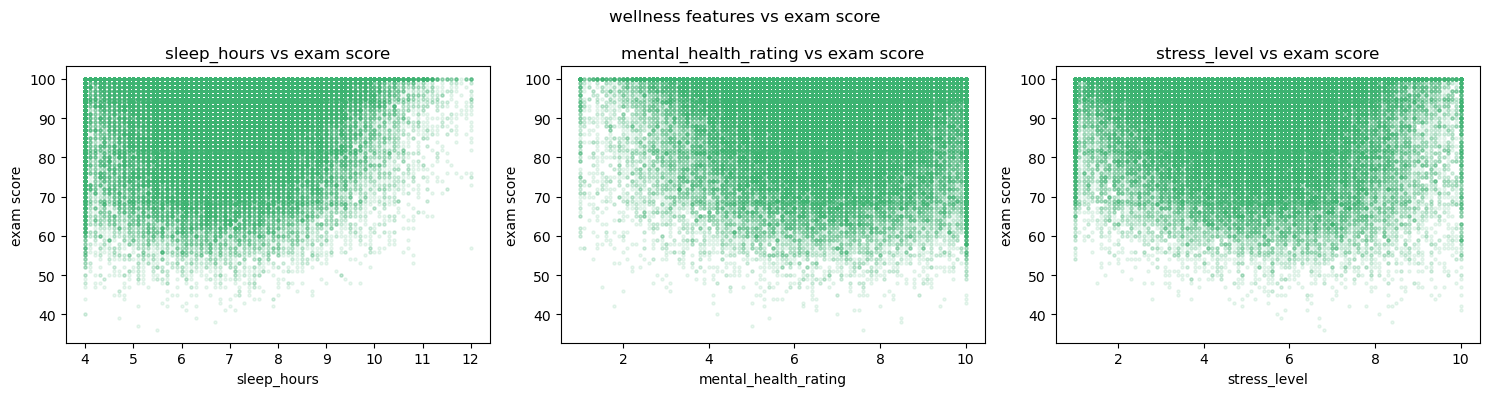

In [12]:
#wellness features vs exam_score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

wellness_cols = ['sleep_hours', 'mental_health_rating', 'stress_level']

for i, col in enumerate(wellness_cols):
    axes[i].scatter(df[col], df['exam_score'],
                    alpha=0.1, color='mediumseagreen', s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('exam score')
    axes[i].set_title(f'{col} vs exam score')

plt.suptitle('wellness features vs exam score', fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_wellness.png", dpi=130)
plt.show()

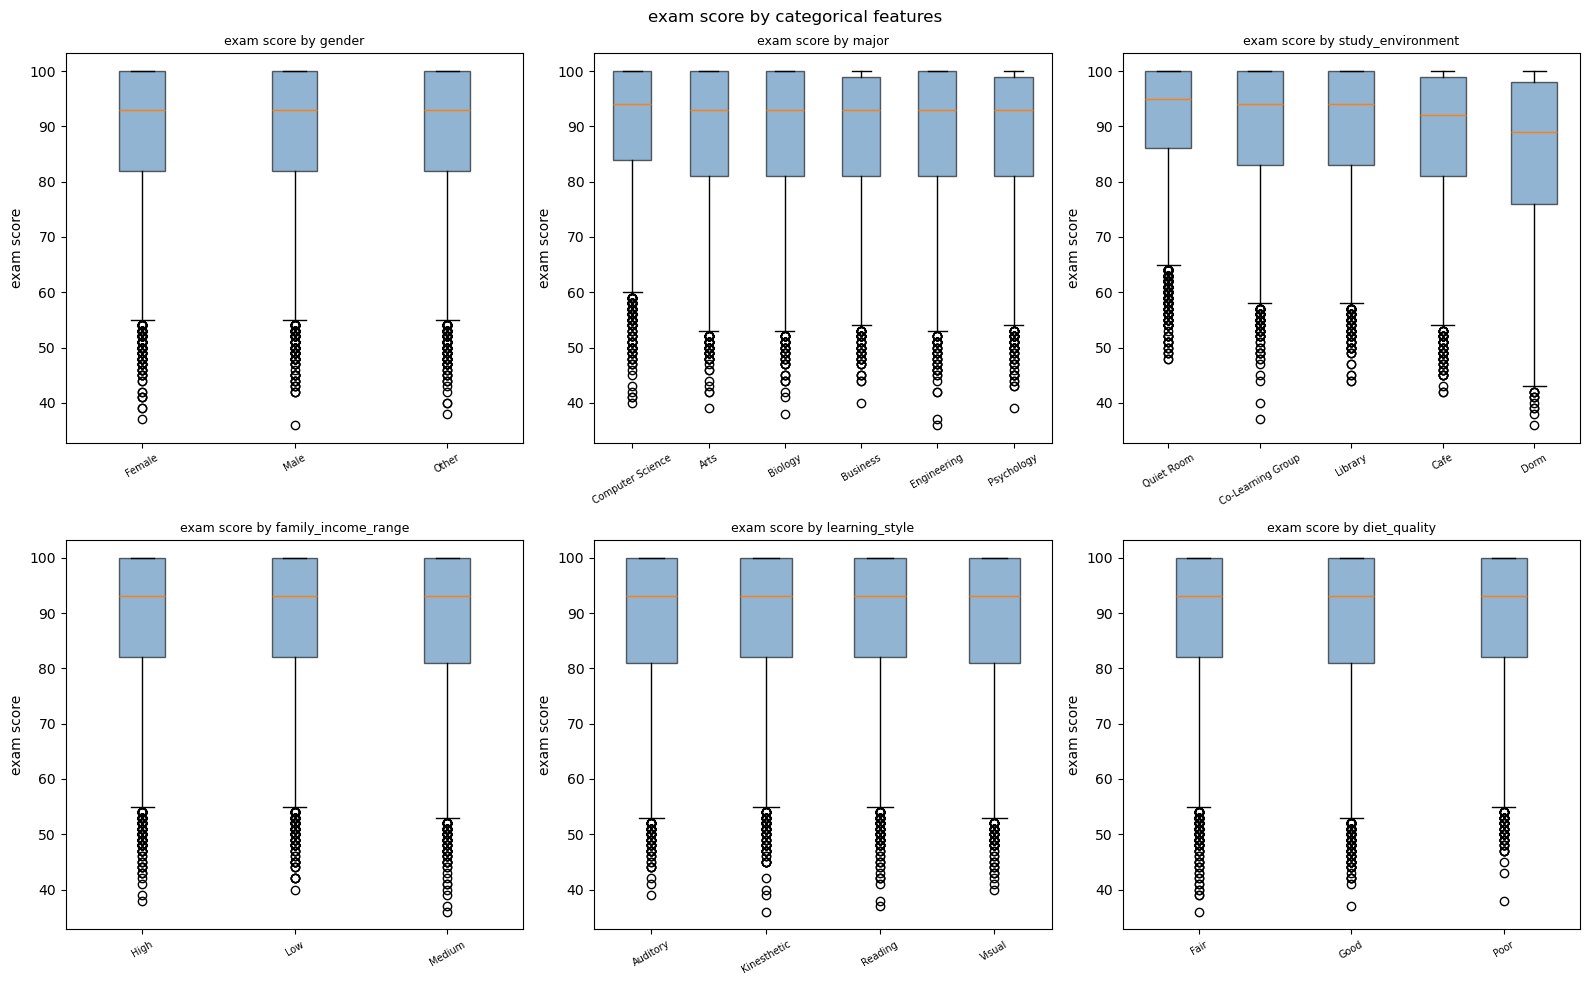

In [13]:
#exam_score by categorical features (boxplots)
cat_to_plot = ['gender', 'major', 'study_environment',
               'family_income_range', 'learning_style', 'diet_quality']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    order = df.groupby(col)['exam_score'].median().sort_values(ascending=False).index
    groups = [df[df[col]==g]['exam_score'].values for g in order]
    axes[i].boxplot(groups, labels=order, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'exam score by {col}', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    axes[i].set_ylabel('exam score')

plt.suptitle('exam score by categorical features', fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_categorical_boxplots.png", dpi=130)
plt.show()

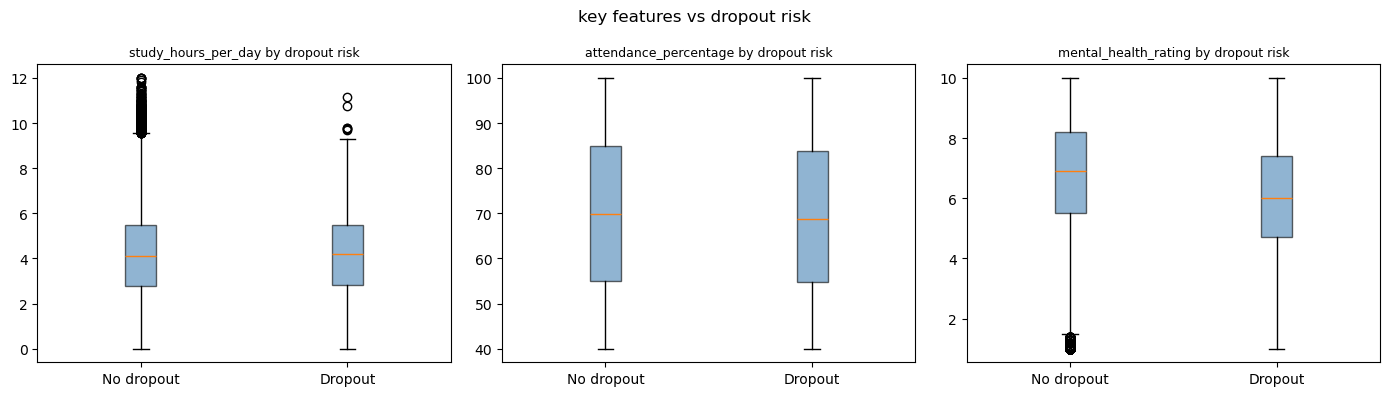

In [14]:
#dropout risk by key features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(['study_hours_per_day', 'attendance_percentage', 'mental_health_rating']):
    dropout_yes = df[df['dropout_risk']=='Yes'][col]
    dropout_no  = df[df['dropout_risk']=='No'][col]
    axes[i].boxplot([dropout_no, dropout_yes],
                    labels=['No dropout','Dropout'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col} by dropout risk', fontsize=9)

plt.suptitle('key features vs dropout risk', fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_dropout_features.png", dpi=130)
plt.show()

In [15]:
#feature engineering preview — wellness score composite
df['wellness_score'] = (
    df['mental_health_rating'] / 10 +
    df['sleep_hours'] / 12 +
    (10 - df['stress_level']) / 10 +
    df['exercise_frequency'] / 7
) / 4

#distraction hours total
df['distraction_hours'] = df['social_media_hours'] + df['netflix_hours']

#study efficiency: study hours relative to distraction
df['study_efficiency'] = df['study_hours_per_day'] / (df['distraction_hours'] + 0.1)

print("composite feature correlations with exam_score:")
for feat in ['wellness_score', 'distraction_hours', 'study_efficiency']:
    corr_val = df[feat].corr(df['exam_score'])
    print(f"  {feat}: {corr_val:.4f}")

composite feature correlations with exam_score:
  wellness_score: 0.1429
  distraction_hours: -0.0058
  study_efficiency: 0.0938


In [16]:
#eda summary
print("=" * 50)
print("  EDA SUMMARY")
print("=" * 50)
print(f"  dataset:        {df.shape[0]:,} students, {df.shape[1]} columns")
print(f"  numeric cols:   {len(num_cols)}")
print(f"  categorical:    {len(cat_cols)}")
print(f"  missing values: 0")
print()
print("  exam_score (regression target):")
print(f"    mean:  {df['exam_score'].mean():.1f}")
print(f"    median:{df['exam_score'].median():.1f}")
print(f"    skew:  {df['exam_score'].skew():.3f}  ← left skewed, ceiling at 100")
print()
print("  dropout_risk (classification target):")
print(f"    No:  {(df['dropout_risk']=='No').sum():,} (98%)")
print(f"    Yes: {(df['dropout_risk']=='Yes').sum():,} (2%)  ← severe imbalance")
print()
print("  key findings:")
print("  - study_hours and attendance most correlated with exam_score")
print("  - social_media and screen_time negatively correlated")
print("  - wellness composite improves correlation over individual features")
print("  - dropout students show lower study hours and attendance")
print("=" * 50)
print()
print("next: 02_sql_layer.ipynb")

  EDA SUMMARY
  dataset:        80,000 students, 35 columns
  numeric cols:   18
  categorical:    12
  missing values: 0

  exam_score (regression target):
    mean:  89.1
    median:93.0
    skew:  -1.028  ← left skewed, ceiling at 100

  dropout_risk (classification target):
    No:  78,418 (98%)
    Yes: 1,582 (2%)  ← severe imbalance

  key findings:
  - study_hours and attendance most correlated with exam_score
  - social_media and screen_time negatively correlated
  - wellness composite improves correlation over individual features
  - dropout students show lower study hours and attendance

next: 02_sql_layer.ipynb


In [17]:
print(df.columns.tolist())
print(df.shape)

['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score', 'grade_tier', 'wellness_score', 'distraction_hours', 'study_efficiency']
(80000, 35)


In [18]:
df.to_csv("../data/processed/cleaned_student_data.csv", index=False)
print("exported cleaned dataset:", df.shape)

exported cleaned dataset: (80000, 35)


In [19]:
df['grade_tier'] = ...
df['study_efficiency'] = ...